<a href="https://colab.research.google.com/github/NANDINI-NANDY123/Play2donate-/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
import numpy as np
import os,cv2
def plot_gallery(images,titles,h,w,n_rows=3,n_col=4):
    plt.figure(figsize=(1.8*n_col,2.4*n_rows)) # Corrected n_row to n_rows
    plt.subplots_adjust(bottom=0,left=.01,right=.99,top=.90,hspace=.35)
    for i in range(n_rows*n_col):
        plt.subplot(n_rows,n_col,i+1)
        # Check if the image array is 2D (tabular data) or 3D (image data)
        if len(images.shape) == 2:
            # If tabular, we need to reshape it for imshow.
            # This assumes h and w are appropriate dimensions for visualization.
            # We'll use gray as default for consistency, but it might not be meaningful.
            if images[i].shape[0] == h*w:
                plt.imshow(images[i].reshape((h,w)),cmap=plt.cm.gray)
            else:
                # If the number of features doesn't match h*w,
                # we cannot reshape it into a square image.
                # For tabular data, image plotting is often not applicable.
                # Display text or skip plotting image if not suitable.
                plt.text(0.5, 0.5, 'N/A', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
        else:
            # If it's already image data (e.g., from fetch_lfw_people), plot directly
            plt.imshow(images[i],cmap=plt.cm.gray)
        plt.title(titles[i],size=12)
        plt.xticks(())
        plt.yticks(())

### Cell 1: Setup and `plot_gallery` function

This cell imports necessary libraries like `matplotlib` for plotting and defines a utility function `plot_gallery`. This function is designed to display a grid of images along with their titles. It handles both 2D (tabular, which it attempts to reshape into images) and 3D (already image-like) array inputs. It sets up the figure size, adjusts subplot spacing, and iterates to plot each image with its corresponding title.

In [ ]:
import numpy as np
from sklearn.datasets import fetch_lfw_people

# Download the LFW dataset if not already on disk
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# introspect the images to find the shapes (width and height)
n_samples, h, w = lfw_people.images.shape

# for machine learning we use the data directly (as relative pixel
# position info is ignored by this model)
X = lfw_people.data
n_features = X.shape[1]

# the label to predict is the id of the person
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]
class_names = target_names.tolist() # Ensure class_names is populated for later use

print("Total dataset size:")
print("n_samples: %d" % n_samples)
print("n_features: %d" % n_features)
print("n_classes: %d" % n_classes)

Total dataset size:
n_samples: 1288
n_features: 1850
n_classes: 7


### Cell 2: Load LFW Dataset and Initial Data Preparation

This cell is responsible for loading the Labeled Faces in the Wild (LFW) dataset. It uses `fetch_lfw_people` from `sklearn.datasets` to download and load faces with at least 70 images per person, resized to 0.4. It then extracts key dimensions (`h`, `w` for height and width), the data matrix `X` (flattened images), and the target labels `y` (person IDs). It also prepares `target_names` and `class_names` for identifying individuals. Finally, it prints a summary of the dataset's size.

In [ ]:
# This cell was used for checking a directory path, which is not relevant for the LFW dataset.
# import os
# path_to_check =r"C:\Users\majji pujitha\OneDrive\Desktop\test_lyst1717074532669.csv"
# print(f"Listing contents of directory: {path_to_check}")
# if os.path.isdir(path_to_check):
#     try:
#         for item in os.listdir(path_to_check):
#             print(item)
#     except Exception as e:
#         print(f"An error occurred while listing directory: {e}")
# else:
#     print(f"Error: Directory '{path_to_check}' not found or is not a directory.")
#     print("Please ensure you have uploaded your dataset and provided the correct path.")

### Cell 3: Unused Directory Check (Commented Out)

This cell contains commented-out code that was likely used for checking a local directory path. It's not actively used in the current notebook's execution flow for the LFW dataset. It demonstrates how one might list the contents of a directory or check if a path exists.

Extracting the top 150 eigenfaces from 966 faces


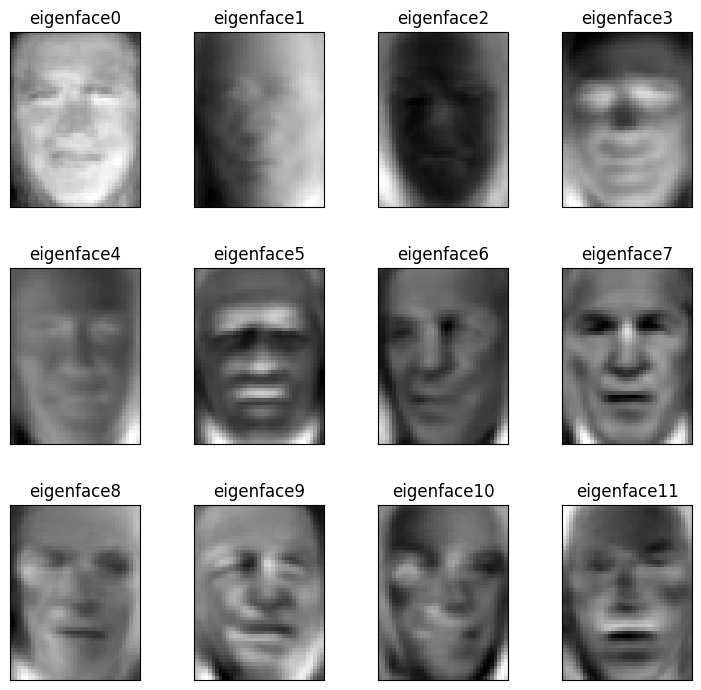

X_train_pca.shape (966, 150)
X_test_pca.shape (322, 150)
Project done...


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42)
n_components=150 # Reverted n_components to a common value for LFW
print("Extracting the top %d eigenfaces from %d faces"% (n_components,X_train.shape[0]))

pca=PCA(n_components=n_components,svd_solver='randomized',whiten=True).fit(X_train)
eigenfaces=pca.components_.reshape((n_components,h,w)) # Uncommented
eigenface_titles=["eigenface%d"% i for i in range(eigenfaces.shape[0])]
plot_gallery(eigenfaces,eigenface_titles,h,w)
plt.show()

X_train_pca=pca.transform(X_train)
X_test_pca=pca.transform(X_test)
print("X_train_pca.shape",X_train_pca.shape)
print("X_test_pca.shape",X_test_pca.shape)
lda=LinearDiscriminantAnalysis()
lda.fit(X_train_pca,y_train)
X_train_lda=lda.transform(X_train_pca)
X_test_lda=lda.transform(X_test_pca)
print("Project done...")

### Cell 4: Data Splitting, PCA, and LDA

This cell performs several crucial data preprocessing steps:

1.  **Data Splitting**: It splits the dataset into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`) using `train_test_split`, allocating 25% for testing and ensuring reproducibility with `random_state=42`.
2.  **PCA (Principal Component Analysis)**: It applies PCA to reduce the dimensionality of the training data. `n_components=150` means it will extract the top 150 principal components (eigenfaces). `svd_solver='randomized'` and `whiten=True` are used for efficient and decorrelated component extraction. The `eigenfaces` are then reshaped for visualization.
3.  **Visualization of Eigenfaces**: The `plot_gallery` function is used to display the extracted eigenfaces.
4.  **Transformation**: Both training and testing data are transformed using the fitted PCA model (`X_train_pca`, `X_test_pca`).
5.  **LDA (Linear Discriminant Analysis)**: It then applies LDA to the PCA-transformed data. LDA is a supervised dimensionality reduction technique that aims to find a linear combination of features that characterizes or separates two or more classes. The data is transformed again (`X_train_lda`, `X_test_lda`).

This sequence of PCA followed by LDA is common in facial recognition to extract the most discriminative features while reducing noise and dimensionality.

In [ ]:
# Re-initialize MLPClassifier to ensure it picks up correct input features from X_train_lda
clf = MLPClassifier(random_state=1, hidden_layer_sizes=(10, 10), max_iter=1000, verbose=True)
clf.fit(X_train_lda, y_train)
print("Model Weights:")
model_info = [coef.shape for coef in clf.coefs_]
print(model_info)

Iteration 1, loss = 2.04161837
Iteration 2, loss = 1.98099742
Iteration 3, loss = 1.92436525
Iteration 4, loss = 1.86993152
Iteration 5, loss = 1.81808373
Iteration 6, loss = 1.76923806
Iteration 7, loss = 1.72287117
Iteration 8, loss = 1.67851435
Iteration 9, loss = 1.63499653
Iteration 10, loss = 1.59300832
Iteration 11, loss = 1.55304673
Iteration 12, loss = 1.51296238
Iteration 13, loss = 1.47514620
Iteration 14, loss = 1.43744769
Iteration 15, loss = 1.40089875
Iteration 16, loss = 1.36555520
Iteration 17, loss = 1.33041499
Iteration 18, loss = 1.29731883
Iteration 19, loss = 1.26476709
Iteration 20, loss = 1.23330251
Iteration 21, loss = 1.20303539
Iteration 22, loss = 1.17404386
Iteration 23, loss = 1.14598042
Iteration 24, loss = 1.11924919
Iteration 25, loss = 1.09348189
Iteration 26, loss = 1.06859213
Iteration 27, loss = 1.04496584
Iteration 28, loss = 1.02217276
Iteration 29, loss = 1.00006962
Iteration 30, loss = 0.97902380
Iteration 31, loss = 0.95851599
Iteration 32, los

### Cell 5: MLPClassifier Training

This cell initializes and trains a Multi-layer Perceptron (MLP) Classifier, which is a type of artificial neural network.

-   `MLPClassifier(random_state=1, hidden_layer_sizes=(10, 10), max_iter=1000, verbose=True)`:
    -   `random_state=1`: Ensures reproducibility of the weight initialization and shuffling.
    -   `hidden_layer_sizes=(10, 10)`: Defines two hidden layers, each with 10 neurons.
    -   `max_iter=1000`: Sets the maximum number of iterations (epochs) for the solver to converge.
    -   `verbose=True`: Prints progress messages during training.

The `clf.fit(X_train_lda, y_train)` line trains the MLP model using the LDA-transformed training data (`X_train_lda`) and the corresponding labels (`y_train`). The output shows the loss decreasing over iterations, indicating the model is learning. Finally, it prints the shape of the model's weights between layers, providing insight into the network architecture.

Accuracy: 84.472049689441


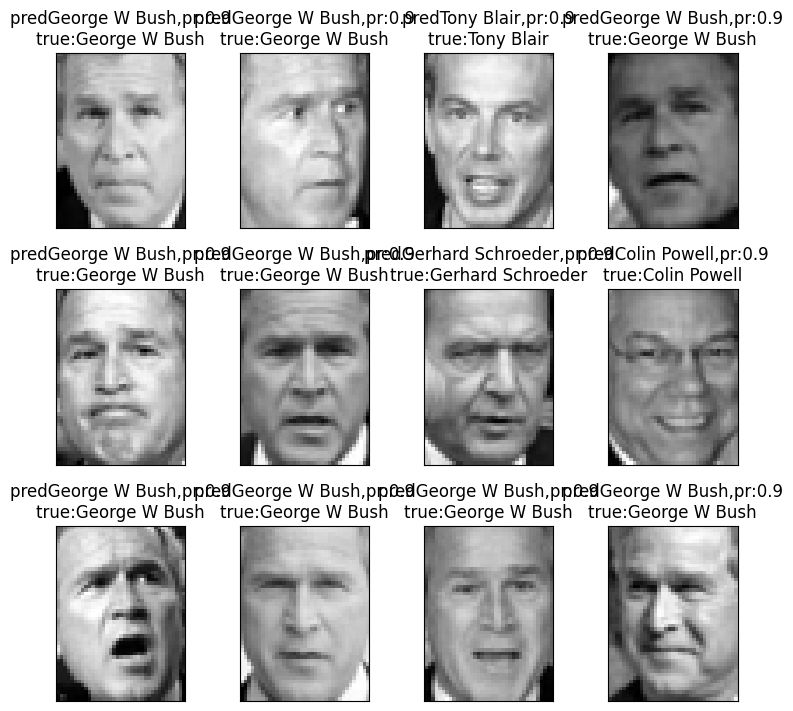

In [ ]:
y_pred=[];y_prob=[]
for test_face in X_test_lda:
  prob=clf.predict_proba([test_face])[0]
  class_id=np.where(prob==np.max(prob))[0][0]
  y_pred.append(class_id)
  y_prob.append(np.max(prob))
y_pred=np.array(y_pred)
prediction_titles=[]
true_positive=0
for i in range(y_pred.shape[0]):
  true_name=class_names[y_test[i]]
  pred_name=class_names[y_pred[i]]
  result='pred%s,pr:%s\ntrue:%s'%(pred_name,str(y_prob[i])[0:3],true_name)
  prediction_titles.append(result)
  if true_name==pred_name:
    true_positive=true_positive+1
print("Accuracy:",true_positive*100/y_pred.shape[0])

# Uncommented plot_gallery for displaying predictions on image data.
plot_gallery(X_test,prediction_titles,h,w)
plt.show()

### Cell 6: Prediction, Accuracy Evaluation, and Visualization

This cell performs predictions using the trained MLP classifier and evaluates its performance:

1.  **Prediction Loop**: It iterates through each test face in `X_test_lda`, uses `clf.predict_proba` to get probability estimates for each class, and selects the class with the highest probability as the prediction. The predicted class ID (`class_id`) and its probability (`prob`) are stored.
2.  **Accuracy Calculation**: It compares the predicted class names (`pred_name`) with the true class names (`true_name`) from `y_test`. It counts `true_positive` predictions and then calculates the overall accuracy.
3.  **Prediction Titles**: For each test image, it constructs a title string showing the predicted name, prediction probability, and the true name.
4.  **Visualization of Predictions**: Finally, it uses the `plot_gallery` function to display a selection of the actual test images (`X_test`), with the generated `prediction_titles` displayed above each image. This allows for a visual assessment of the model's performance.